In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import json
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import warnings
warnings.filterwarnings('ignore')


In [4]:
# (CHANGE THESE ACCORDING TO YOUR DRIVE)
STUDENTLIFE_PATH = "/content/drive/MyDrive/AI Project - Academic Burnout/Data"
#OUTPUT_PATH = "/content/drive/MyDrive/AI_Burnout_Predictor/results_realistic_studentlife"

#os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Paths configured.")


Paths configured.


In [5]:
# Loading StudentLife data
def load_studentlife_json(folder_path):
    all_data = []
    for file_name in os.listdir(folder_path):
        if file_name.endswith(".json"):
            student_id = file_name.replace(".json", "")
            with open(os.path.join(folder_path, file_name), "r") as f:
                records = json.load(f)
                for r in records:
                    r["student_id"] = student_id
                    all_data.append(r)
    return pd.DataFrame(all_data)

print("Loading StudentLife...")

stress_raw = load_studentlife_json(os.path.join(STUDENTLIFE_PATH, "Stress"))
activity_raw = load_studentlife_json(os.path.join(STUDENTLIFE_PATH, "Activity"))
sleep_raw = load_studentlife_json(os.path.join(STUDENTLIFE_PATH, "Sleep"))

print(f"Stress: {stress_raw.shape}")
print(f"Activity: {activity_raw.shape}")
print(f"Sleep: {sleep_raw.shape}")


Loading StudentLife...
Stress: (2408, 5)
Activity: (833, 9)
Sleep: (1644, 7)


In [6]:
stress_raw.head()

,level,location,resp_time,student_id,null
0,3,"43.70712148268646,-72.29087061546424",1364681195,Stress_u49,NaN
1,NaN,NaN,1364121911,Stress_u49,1
2,NaN,NaN,1364121426,Stress_u49,1
3,NaN,NaN,1364121429,Stress_u49,1
4,NaN,NaN,1364118814,Stress_u49,"43.70633605,-72.28701846"


In [7]:
activity_raw.head()

,Social2,null,resp_time,student_id,other_relaxing,other_working,relaxing,working,location
0,2,3,1364853391,Activity_u12,NaN,NaN,NaN,NaN,NaN
1,3,4,1364359262,Activity_u12,NaN,NaN,NaN,NaN,NaN
2,2,1,1364592822,Activity_u12,NaN,NaN,NaN,NaN,NaN
3,3,1,1364420311,Activity_u12,NaN,NaN,NaN,NaN,NaN
4,3,1,1364537832,Activity_u12,NaN,NaN,NaN,NaN,NaN


In [8]:
sleep_raw.head()

,null,resp_time,student_id,hour,location,rate,social
0,"43.70643224,-72.28718618",1364121462,Sleep_u25,NaN,NaN,NaN,NaN
1,7,1364118945,Sleep_u25,NaN,NaN,NaN,NaN
2,"43.70643224,-72.28718618",1364121461,Sleep_u25,NaN,NaN,NaN,NaN
3,2,1364121789,Sleep_u25,NaN,NaN,NaN,NaN
4,"43.70643224,-72.28718618",1364121464,Sleep_u25,NaN,NaN,NaN,NaN


In [9]:
# Cleaning the STRESS DATASET
# =========================
print("\n DATASET: STRESS")
print("Shows self-reported student stress levels over time")

print("\nCleaning StudentLife Stress...")

stress_clean = stress_raw.copy()

# Dropping the 'null' column
if 'null' in stress_clean.columns:
    stress_clean = stress_clean.drop(columns=['null'])

print("\nInitial Stress Dataset:")
print(stress_clean)

# Converting  timestamp
stress_clean['timestamp'] = pd.to_datetime(stress_clean['resp_time'], unit='s')
print("\nAfter converting resp_time to timestamp:")
print(stress_clean)

# Cleaning  student_id
stress_clean['student_id'] = stress_clean['student_id'].str.replace('Stress_', '')
print("\nAfter cleaning student_id:")
print(stress_clean)



 DATASET: STRESS
Shows self-reported student stress levels over time

Cleaning StudentLife Stress...

Initial Stress Dataset:
     level                              location   resp_time  student_id
0        3  43.70712148268646,-72.29087061546424  1364681195  Stress_u49
1      NaN                                   NaN  1364121911  Stress_u49
2      NaN                                   NaN  1364121426  Stress_u49
3      NaN                                   NaN  1364121429  Stress_u49
4      NaN                                   NaN  1364118814  Stress_u49
...    ...                                   ...         ...         ...
2403     2              43.70390811,-72.29065789  1369368560  Stress_u16
2404     2              43.70675104,-72.28740962  1369349334  Stress_u16
2405     1              43.70372826,-72.29097234  1369428881  Stress_u16
2406     3              43.68753666,-72.29250241  1369719704  Stress_u16
2407     3              43.68753666,-72.29250241  1369729103  Stress_u

In [10]:
#renaming the level column
stress_clean = stress_clean.rename(columns={'level': 'stress_level'})
print("\nAfter renaming level → stress_level:")
print(stress_clean)

#Converting stress_level to numeric data
stress_clean['stress_level'] = pd.to_numeric(stress_clean['stress_level'], errors='coerce')
print("\nAfter converting stress_level to numeric:")
print(stress_clean)

#dropping missing stress values
stress_clean = stress_clean.dropna(subset=['stress_level'])
print("\nAfter dropping NaN stress levels:")
print(stress_clean)

#Explicit float conversion
stress_clean['stress_level'] = stress_clean['stress_level'].astype(float)
print("\nFinal cleaned Stress dataset:")
print(stress_clean)



After renaming level → stress_level:
     stress_level                              location   resp_time  \
0               3  43.70712148268646,-72.29087061546424  1364681195   
1             NaN                                   NaN  1364121911   
2             NaN                                   NaN  1364121426   
3             NaN                                   NaN  1364121429   
4             NaN                                   NaN  1364118814   
...           ...                                   ...         ...   
2403            2              43.70390811,-72.29065789  1369368560   
2404            2              43.70675104,-72.28740962  1369349334   
2405            1              43.70372826,-72.29097234  1369428881   
2406            3              43.68753666,-72.29250241  1369719704   
2407            3              43.68753666,-72.29250241  1369729103   

     student_id           timestamp  
0           u49 2013-03-30 22:06:35  
1           u49 2013-03-24 10:45:

In [11]:
# Code for Activity data cleaning
print("\n DATASET: ACTIVITY")
print(" Shows students' daily activity levels (social, working, relaxing)")

print("\nCleaning StudentLife Activity")

activity_clean = activity_raw.copy()

# Drop the 'null' coloumns
if 'null' in activity_clean.columns:
    activity_clean = activity_clean.drop(columns=['null'])

print("\nInitial Activity Dataset:")
print(activity_clean)

# Convert timestamp

activity_clean['timestamp'] = pd.to_datetime(activity_clean['resp_time'], unit='s')
print("\nAfter converting resp_time to timestamp:")
print(activity_clean)

# Clean student_id
activity_clean['student_id'] = activity_clean['student_id'].str.replace('Activity_', '')
print("\nAfter cleaning student_id:")
print(activity_clean)



 DATASET: ACTIVITY
 Shows students' daily activity levels (social, working, relaxing)

Cleaning StudentLife Activity

Initial Activity Dataset:
    Social2   resp_time    student_id other_relaxing other_working relaxing  \
0         2  1364853391  Activity_u12            NaN           NaN      NaN   
1         3  1364359262  Activity_u12            NaN           NaN      NaN   
2         2  1364592822  Activity_u12            NaN           NaN      NaN   
3         3  1364420311  Activity_u12            NaN           NaN      NaN   
4         3  1364537832  Activity_u12            NaN           NaN      NaN   
..      ...         ...           ...            ...           ...      ...   
828     NaN  1365754502  Activity_u30              3             3        1   
829     NaN  1366495759  Activity_u30              2             1        1   
830     NaN  1366575978  Activity_u30              2             2        1   
831     NaN  1367258363  Activity_u30              2             

In [12]:


# key columns of studentlife dataset

for col in ["Social2", "working", "other_working", "relaxing", "other_relaxing"]:
    if col not in activity_clean.columns:
        activity_clean[col] = np.nan



# Converting to numeric

for col in ["Social2", "working", "other_working", "relaxing", "other_relaxing"]:
  activity_clean[col] = pd.to_numeric(activity_clean[col], errors="coerce")



# Computing interpretable scores

activity_clean["workload_score"] = activity_clean[["working", "other_working"]].sum(axis=1, min_count=1)
activity_clean["recovery_score"] = activity_clean[["relaxing", "other_relaxing"]].sum(axis=1, min_count=1)
activity_clean["social_score"] = activity_clean["Social2"]


print("\nAfter computing workload_score / recovery_score / social_score:")

print(activity_clean[["student_id", "timestamp", "workload_score", "recovery_score", "social_score"]].head())



# Keep relevant columns and drop rows where ALL scores are missing

activity_clean = activity_clean[["student_id", "timestamp", "workload_score", "recovery_score", "social_score"]]
activity_clean = activity_clean.dropna( subset=["workload_score", "recovery_score", "social_score"], how="all" ).copy()



print("\nFinal cleaned Activity dataset (3 scores):")
print(activity_clean.head())




After computing workload_score / recovery_score / social_score:
  student_id           timestamp  workload_score  recovery_score  social_score
0        u12 2013-04-01 21:56:31             NaN             NaN           2.0
1        u12 2013-03-27 04:41:02             NaN             NaN           3.0
2        u12 2013-03-29 21:33:42             NaN             NaN           2.0
3        u12 2013-03-27 21:38:31             NaN             NaN           3.0
4        u12 2013-03-29 06:17:12             NaN             NaN           3.0

Final cleaned Activity dataset (3 scores):
  student_id           timestamp  workload_score  recovery_score  social_score
0        u12 2013-04-01 21:56:31             NaN             NaN           2.0
1        u12 2013-03-27 04:41:02             NaN             NaN           3.0
2        u12 2013-03-29 21:33:42             NaN             NaN           2.0
3        u12 2013-03-27 21:38:31             NaN             NaN           3.0
4        u12 2013-03-2

In [13]:
# Sleep dataset processing

# Print dataset name
print("\ DATASET: SLEEP")

# Describe dataset purpose
print("Shows students' self-reported sleep duration in hours")

# Start cleaning process
print("\nCleaning StudentLife Sleep...")

# Create a copy of raw dataset
sleep_clean = sleep_raw.copy()

# Remove irrelevant null column if present
if 'null' in sleep_clean.columns:
    sleep_clean = sleep_clean.drop(columns=['null'])

# Display initial dataset
print("\nInitial Sleep Dataset:")
print(sleep_clean)

# Convert response time to timestamp
sleep_clean['timestamp'] = pd.to_datetime(sleep_clean['resp_time'], unit='s')

# Show dataset after timestamp conversion
print("\nAfter converting resp_time to timestamp:")
print(sleep_clean)

\ DATASET: SLEEP
Shows students' self-reported sleep duration in hours

Cleaning StudentLife Sleep...

Initial Sleep Dataset:
       resp_time student_id hour                  location rate social
0     1364121462  Sleep_u25  NaN                       NaN  NaN    NaN
1     1364118945  Sleep_u25  NaN                       NaN  NaN    NaN
2     1364121461  Sleep_u25  NaN                       NaN  NaN    NaN
3     1364121789  Sleep_u25  NaN                       NaN  NaN    NaN
4     1364121464  Sleep_u25  NaN                       NaN  NaN    NaN
...          ...        ...  ...                       ...  ...    ...
1639  1365962124  Sleep_u23    8   43.7050633,-72.28352333    1      1
1640  1366047881  Sleep_u23    8  43.70548232,-72.28294733    1      1
1641  1366220438  Sleep_u23    6  43.70563203,-72.28296566    1      1
1642  1366491749  Sleep_u23    8  43.70587021,-72.28397539    1      1
1643  1366650172  Sleep_u23    6  43.70500519,-72.28332888    1      1

[1644 rows x 6 column

In [14]:
# Clean student_id by removing prefix
sleep_clean['student_id'] = sleep_clean['student_id'].str.replace('Sleep_', '')

# Show dataset after cleaning student_id
print("\nAfter cleaning student_id:")
print(sleep_clean)

# Convert hour column to numeric sleep_hours
sleep_clean['sleep_hours'] = pd.to_numeric(sleep_clean['hour'], errors='coerce')

# Show dataset after converting sleep hours
print("\nAfter converting hour to sleep_hours:")
print(sleep_clean)

# Keep only relevant columns and remove missing values
sleep_clean = sleep_clean[['student_id', 'timestamp', 'sleep_hours']].dropna()

# Display final cleaned dataset
print("\nFinal cleaned Sleep dataset:")
print(sleep_clean)


After cleaning student_id:
       resp_time student_id hour                  location rate social  \
0     1364121462        u25  NaN                       NaN  NaN    NaN   
1     1364118945        u25  NaN                       NaN  NaN    NaN   
2     1364121461        u25  NaN                       NaN  NaN    NaN   
3     1364121789        u25  NaN                       NaN  NaN    NaN   
4     1364121464        u25  NaN                       NaN  NaN    NaN   
...          ...        ...  ...                       ...  ...    ...   
1639  1365962124        u23    8   43.7050633,-72.28352333    1      1   
1640  1366047881        u23    8  43.70548232,-72.28294733    1      1   
1641  1366220438        u23    6  43.70563203,-72.28296566    1      1   
1642  1366491749        u23    8  43.70587021,-72.28397539    1      1   
1643  1366650172        u23    6  43.70500519,-72.28332888    1      1   

               timestamp  
0    2013-03-24 10:37:42  
1    2013-03-24 09:55:45  
2 

In [15]:
# Sahitya_week2 added code for feature engineering for stress dataset
print("CREATING WEEKLY STUDENTLIFE FEATURES (STRESS + SLEEP + ACTIVITY)")

for df, time_col in [  # loop through each dataframe and its timestamp column name

    (stress_clean, "timestamp"),  # pair: stress dataframe + timestamp column

    (activity_clean, "timestamp"),  # pair: activity dataframe + timestamp column

    (sleep_clean, "timestamp"),  # pair: sleep dataframe + timestamp column

]:

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")  # convert to datetime;

sleep_clean.head()

CREATING WEEKLY STUDENTLIFE FEATURES (STRESS + SLEEP + ACTIVITY)


,student_id,timestamp,sleep_hours
5,u25,2013-03-30 18:15:44,9.0
6,u25,2013-03-28 17:54:22,8.0
7,u25,2013-04-02 17:20:27,8.0
8,u25,2013-04-01 05:27:26,8.0
9,u25,2013-04-01 04:11:26,7.0


the following code is written by jaimil kothari - week 2

In [16]:


def add_student_zscore(df, id_col, value_col, new_col, time_col=None):  # to define helper function to add a z-score column

    if time_col is None:  # checking if a time column name was provided or not
        # falling back to index order if timestamp isn't provided
        time_col = None  # keeping it none explicitly

    if time_col is not None and time_col in df.columns:  # if time_col exists then doing sort by id + time
        df = df.sort_values([id_col, time_col]).copy()  # sorting data to ensure expanding stats follow time order

    else:  # else sort only by student id
        df = df.sort_values([id_col]).copy()  # sorting by student id for deterministic order

    def _exp_z(s: pd.Series) -> pd.Series:  # this is an inner function to compute expanding z-score for one student series
        exp_mean = s.expanding(min_periods=1).mean()  # expanding mean up to each point
        exp_std = s.expanding(min_periods=2).std().fillna(0.0)  # expanding std; needs >=2 points
        exp_std = exp_std.replace(0, np.nan).fillna(1.0)  # replacing 0 std with 1 to avoid divide-by-zero
        return (s - exp_mean) / exp_std  # computing z-score using expanding mean/std


    df[new_col] = df.groupby(id_col)[value_col].transform(_exp_z)  # expanding z-score per student
    return df  # returning dataframe with new z-score column added


stress_clean = add_student_zscore(stress_clean, "student_id", "stress_level", "stress_z", time_col="timestamp")  # adding stress_z

for col, zcol in [("workload_score","workload_z"),("recovery_score","recovery_z"),("social_score","social_z")]:  # mapping activity cols to z cols
    if col in activity_clean.columns:  # true only if the activity column exists
        activity_clean = add_student_zscore(activity_clean, "student_id", col, zcol, time_col="timestamp")  # adding corresponding z-score column

sleep_clean = add_student_zscore(sleep_clean, "student_id", "sleep_hours", "sleep_z")  # adding sleep_z (no time_col passed here)

In [17]:
stress_clean.head()

,stress_level,location,resp_time,student_id,timestamp,stress_z
2078,2.0,"43.70692415,-72.2873929",1364237696,u00,2013-03-25 18:54:56,0.000000
2079,2.0,"43.70555193,-72.28704778",1364268806,u00,2013-03-26 03:33:26,0.000000
2080,2.0,"43.70555193,-72.28704778",1364268814,u00,2013-03-26 03:33:34,0.000000
2081,1.0,"43.70678675,-72.28732051",1364346740,u00,2013-03-27 01:12:20,-1.500000
2083,1.0,"43.70508322,-72.28677496",1364437527,u00,2013-03-28 02:25:27,-1.095445


In [18]:
sleep_clean.head(100)

,student_id,timestamp,sleep_hours,sleep_z
145,u00,2013-05-28 17:54:35,9.0,0.000000
109,u00,2013-04-05 17:00:15,4.0,-0.707107
108,u00,2013-04-04 17:06:33,10.0,0.725866
107,u00,2013-04-01 17:11:06,3.0,-0.996616
106,u00,2013-03-31 17:24:17,9.0,0.617213
...,...,...,...,...
791,u02,2013-04-21 19:30:09,8.0,-0.171240
792,u02,2013-04-22 18:08:04,8.0,-0.165683
793,u02,2013-04-25 22:01:21,7.0,-0.934262
794,u02,2013-04-26 17:14:25,6.0,-1.568929




---


The following code is done by Md Israk Hossain, Week 2


---





In [19]:

# ISO weeks are a standard calendar system used worldwide. They keep “week numbers” consistent (weeks starting on Monday), making weekly grouping more reliable.
stress_clean["week"] = stress_clean["timestamp"].dt.isocalendar().week.astype(int)  # taking the ISO week number from each stress timestamp and storing it as an int
activity_clean["week"] = activity_clean["timestamp"].dt.isocalendar().week.astype(int)  # adding ISO week number for each activity record
sleep_clean["week"] = sleep_clean["timestamp"].dt.isocalendar().week.astype(int)  # adding ISO week number for each sleep record


# starting to build a new dataframe containing weekly stress summaries. Here we are computing multiple summary stats for each student-week group
stress_weekly = (
    stress_clean.groupby(["student_id", "week"]).agg(
        stress_mean=("stress_level", "mean"),  # calculating average stress level during that week
        stress_std=("stress_level", "std"),  # measuring how much stress varies during that week
        stress_max=("stress_level", "max"),  # finding the highest stress level recorded in that week
        stress_count=("stress_level", "count"),  # counting how many stress readings exist in that week
        stress_z_mean=("stress_z", "mean"),  # calculating average normalized stress (z-score) in that week
        stress_z_std=("stress_z", "std"),  # measuring variation of normalized stress (z-score) in that week
        stress_z_max=("stress_z", "max"), ).reset_index() ) # finding the maximum normalized stress (z-score) in that week


agg_dict = {}  # creating a dictionary to store aggregation rules

for prefix, val_col, z_col in [  # looping through each activity score and its z-score column
    ("workload", "workload_score", "workload_z"),
    ("recovery", "recovery_score", "recovery_z"),
    ("social", "social_score", "social_z")]:

    if val_col in activity_clean.columns:  # checking if the raw score column exists
        agg_dict.update({  # adding aggregation rules for raw values
            f"{prefix}_mean": (val_col, "mean"),  # calculating weekly average
            f"{prefix}_std": (val_col, "std"),  # measuring weekly variation
            f"{prefix}_max": (val_col, "max"),  # finding weekly maximum value
            f"{prefix}_count": (val_col, "count"), }) # counting number of records in that week


    if z_col in activity_clean.columns:  # checking if normalized z-score column exists. If yes, we add aggregation rules for z-score values
        agg_dict.update({
            f"{prefix}_z_mean": (z_col, "mean"),  # calculating weekly average z-score
            f"{prefix}_z_std": (z_col, "std"),  # measuring weekly variation of z-scores
            f"{prefix}_z_max": (z_col, "max"),})  # finding highest z-score in that week

# building weekly activity summary dataframe
activity_weekly = (
    activity_clean.groupby(["student_id", "week"])  # grouping activity rows by student and week
    .agg(**agg_dict)  # applying all prepared aggregation rules
    .reset_index())   # converting grouped index back into normal columns

# building weekly sleep summary dataframe
sleep_weekly = (
    sleep_clean.groupby(["student_id", "week"]).agg(
        sleep_mean=("sleep_hours", "mean"),  # calculating weekly average sleep hours
        sleep_std=("sleep_hours", "std"),  # measuring variation of sleep hours during the week
        sleep_count=("sleep_hours", "count"),  # counting sleep records in that week
        sleep_z_mean=("sleep_z", "mean"),  # calculating weekly average normalized sleep (z-score)
        sleep_z_std=("sleep_z", "std"), ).reset_index())  # measuring variation of normalized sleep (z-score)

# building final feature table (one row per student per week)
studentlife_features = (
    stress_weekly  # using weekly stress table as the base
    .merge(activity_weekly, on=["student_id", "week"], how="left")  # attaching weekly activity features
    .merge(sleep_weekly, on=["student_id", "week"], how="left")  # attaching weekly sleep features
)

# final table containing the StudentLife multimodal weekly dataset (stress + activity + sleep together)
multimodal_df = studentlife_features.copy()  # creating a copy to avoid accidental modification of the original

In [20]:
multimodal_df.head()

,student_id,week,stress_mean,stress_std,stress_max,stress_count,stress_z_mean,stress_z_std,stress_z_max,workload_mean,...,social_max,social_count,social_z_mean,social_z_std,social_z_max,sleep_mean,sleep_std,sleep_count,sleep_z_mean,sleep_z_std
0,u00,13,2.705882,1.358524,5.0,17,0.477033,1.154053,2.035527,NaN,...,3.0,5.0,0.203169,0.926565,1.434274,7.083333,1.621354,12.0,0.107002,0.535603
1,u00,14,2.181818,1.470930,5.0,11,-0.252880,1.063170,1.784366,NaN,...,2.0,6.0,-0.184553,0.705472,0.333333,6.666667,3.011091,6.0,-0.035734,0.892648
2,u00,15,2.166667,0.983192,3.0,6,-0.223616,0.708273,0.420137,5.400000,...,2.0,1.0,0.402200,NaN,0.402200,7.000000,3.391165,9.0,-0.081765,1.184355
3,u00,16,3.333333,0.516398,4.0,6,0.645965,0.375674,1.147061,4.333333,...,NaN,0.0,NaN,NaN,NaN,5.000000,2.738613,5.0,-0.716467,0.931478
4,u00,17,1.000000,0.000000,1.0,4,-1.146164,0.040471,-1.100449,5.200000,...,NaN,0.0,NaN,NaN,NaN,5.750000,2.500000,4.0,-0.516819,0.865463




---


The following code is done by Sahitya, Week 3


---





In [21]:
# Sahitya_week3 Created Target Variable

# Define proxy burnout risk label (multi-signal, 2-week-ahead)

print("CREATING TARGET LABEL (PROXY)")

# Two-week-ahead outcomes (ONLY for the label, never used as input features)

multimodal_df["future_stress_2w"] = multimodal_df.groupby("student_id")["stress_mean"].shift(-2)

multimodal_df["future_sleep_2w"]  = multimodal_df.groupby("student_id")["sleep_mean"].shift(-2)



# Keep only rows where we can define the 2-week-ahead outcome

multimodal_df = multimodal_df.dropna(subset=["future_stress_2w", "future_sleep_2w"]).reset_index(drop=True)



# Data-adaptive thresholds (quantile search)

# We try a small grid of quantiles and pick the pair that yields a reasonable positive rate.

# Target: ~10% to ~30% positives (enough signal, but not too many).

stress_q_candidates = [0.65, 0.70, 0.75, 0.80]

sleep_q_candidates  = [0.35, 0.30, 0.25, 0.20]



target_rate = 0.15

min_rate, max_rate = 0.10, 0.30



best = None  # (score, stress_q, sleep_q, stress_th, sleep_th, pos_rate, pos_count)



for sq in stress_q_candidates:

    stress_th = multimodal_df["future_stress_2w"].quantile(sq)

    for lq in sleep_q_candidates:

        sleep_th = multimodal_df["future_sleep_2w"].quantile(lq)



        y = ((multimodal_df["future_stress_2w"] >= stress_th) &

             (multimodal_df["future_sleep_2w"]  <= sleep_th)).astype(int)



        pos_rate = float(y.mean())

        pos_count = int(y.sum())



        # Score: prefer rates in [min_rate, max_rate] and close to target_rate

        in_range = (min_rate <= pos_rate <= max_rate)

        score = abs(pos_rate - target_rate) + (0 if in_range else 0.5)  # penalty if out of range



        if best is None or score < best[0]:

            best = (score, sq, lq, float(stress_th), float(sleep_th), pos_rate, pos_count)



_, STRESS_Q, SLEEP_Q, STRESS_TH, SLEEP_TH, POS_RATE, POS_COUNT = best



multimodal_df["burnout_risk"] = (

    (multimodal_df["future_stress_2w"] >= STRESS_TH) &

    (multimodal_df["future_sleep_2w"]  <= SLEEP_TH)

).astype(int)



print("Label created: burnout_risk")

print(f"Chosen stress quantile: {STRESS_Q}  -> STRESS_TH = {STRESS_TH:.3f}")

print(f"Chosen sleep  quantile: {SLEEP_Q}  -> SLEEP_TH  = {SLEEP_TH:.3f}")

print(f"Positive rate: {POS_RATE:.3f}  |  Positives: {POS_COUNT} / {len(multimodal_df)}")

print("Class distribution:")

print(multimodal_df["burnout_risk"].value_counts(dropna=False))



CREATING TARGET LABEL (PROXY)
Label created: burnout_risk
Chosen stress quantile: 0.65  -> STRESS_TH = 2.512
Chosen sleep  quantile: 0.35  -> SLEEP_TH  = 7.000
Positive rate: 0.164  |  Positives: 34 / 207
Class distribution:
burnout_risk
0    173
1     34
Name: count, dtype: int64




---





---


The following code is done by Ronit, Week 3


---





In [22]:
# Prepare feature sets (baseline vs multimodal)

print("="*70)

print("PREPARING FEATURE SETS")

print("="*70)



y = multimodal_df["burnout_risk"].astype(int)



# Three feature sets (Ablation Study)

# A) Stress-only

# B) Stress + Sleep

# C) Stress + Sleep + Activity (Full Multimodal)



baseline_cols = [

    # raw stress stats

    "stress_mean","stress_std","stress_max","stress_count",

    # normalized stress stats (deviation from personal baseline)

    "stress_z_mean","stress_z_std","stress_z_max",

    # temporal stress features (raw + z)

    "stress_mean_diff1","stress_mean_diff2",

    "stress_z_mean_diff1","stress_z_mean_diff2",

    "stress_mean_roll4_mean","stress_mean_roll4_std",

    "stress_z_mean_roll4_mean","stress_z_mean_roll4_std",

    # missingness flags

    "stress_missing"

]



stress_sleep_cols = baseline_cols + [

    "sleep_mean","sleep_std","sleep_count",

    "sleep_z_mean","sleep_z_std",

    "sleep_mean_diff1","sleep_mean_diff2",

    "sleep_z_mean_diff1","sleep_z_mean_diff2",

    "sleep_mean_roll4_mean","sleep_mean_roll4_std",

    "sleep_z_mean_roll4_mean","sleep_z_mean_roll4_std",

]



multimodal_cols = stress_sleep_cols + [

    # Workload (working-related)

    "workload_mean","workload_std","workload_max","workload_count",

    "workload_z_mean","workload_z_std","workload_z_max",

    "workload_mean_diff1","workload_mean_diff2",

    "workload_z_mean_diff1","workload_z_mean_diff2",

    "workload_mean_roll4_mean","workload_mean_roll4_std",

    "workload_z_mean_roll4_mean","workload_z_mean_roll4_std",



    # Recovery (relaxing-related)

    "recovery_mean","recovery_std","recovery_max","recovery_count",

    "recovery_z_mean","recovery_z_std","recovery_z_max",

    "recovery_mean_diff1","recovery_mean_diff2",

    "recovery_z_mean_diff1","recovery_z_mean_diff2",

    "recovery_mean_roll4_mean","recovery_mean_roll4_std",

    "recovery_z_mean_roll4_mean","recovery_z_mean_roll4_std",



    # Social interaction (Social2)

    "social_mean","social_std","social_max","social_count",

    "social_z_mean","social_z_std","social_z_max",

    "social_mean_diff1","social_mean_diff2",

    "social_z_mean_diff1","social_z_mean_diff2",

    "social_mean_roll4_mean","social_mean_roll4_std",

    "social_z_mean_roll4_mean","social_z_mean_roll4_std",

]



# Add missingness flags (if present)

multimodal_cols += ["workload_missing","recovery_missing","social_missing"]



# Keep only columns that exist (not all datasets have all stats)

baseline_cols     = [c for c in baseline_cols     if c in multimodal_df.columns]

stress_sleep_cols = [c for c in stress_sleep_cols if c in multimodal_df.columns]

multimodal_cols   = [c for c in multimodal_cols   if c in multimodal_df.columns]



X_baseline     = multimodal_df[baseline_cols].copy()

X_stress_sleep = multimodal_df[stress_sleep_cols].copy()

X_multimodal   = multimodal_df[multimodal_cols].copy()



groups = multimodal_df["student_id"]

weeks  = multimodal_df["week"]



print("Feature sets ready:")

print("  A) Stress-only:     ", X_baseline.shape)

print("  B) Stress+Sleep:    ", X_stress_sleep.shape)

print("  C) Full Multimodal: ", X_multimodal.shape)

PREPARING FEATURE SETS
Feature sets ready:
  A) Stress-only:      (207, 7)
  B) Stress+Sleep:     (207, 12)
  C) Full Multimodal:  (207, 33)




---


The following code is done by Md Israk Hossain, Week 3


---





In [23]:
# Defining models and parameter grids
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

print("Setting up GridSearchCV models...")

# We keep a small grid so it runs in reasonable time.
# We are using class_weight where supported because burnout-risk is often imbalanced.

models_and_params = {
    "LogReg": {
        "model": LogisticRegression(max_iter=2000, class_weight="balanced"),
        "params": {
            "model__C": [0.1, 1.0, 10.0]
        }
    },
    "RandomForest": {
        "model": RandomForestClassifier(random_state=42, class_weight="balanced"),
        "params": {
            "model__n_estimators": [200, 500],
            "model__max_depth": [5, 10, None],
            "model__min_samples_split": [2, 10]
        }
    },
    "GradientBoosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 300],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [2, 3]
        }
    },
    "SVM": {
        "model": SVC(probability=True, class_weight="balanced"),
        "params": {
            "model__C": [0.5, 1.0, 2.0],
            "model__kernel": ["rbf"]
        }
    }
}

print("Models ready:", list(models_and_params.keys()))


Setting up GridSearchCV models...
Models ready: ['LogReg', 'RandomForest', 'GradientBoosting', 'SVM']


In [24]:
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score
import numpy as np

def run_gridsearch(X, y, groups, model_dict, dataset_name, weeks=None):

    # Printing section header for clarity
    print(f"\n{'='*70}")
    print(f"GridSearchCV for {dataset_name} (Group-wise by student)")
    print(f"{'='*70}")

    # Creating group-based train/test split to prevent student identity leakage
    # Ensuring each student is only appearing in either train or test set
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)

    # Generating indices for train and test sets
    train_idx, test_idx = next(gss.split(X, y, groups=groups))

    # Creating training and testing feature sets
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]

    # Creating training and testing labels
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Storing group identifiers for train and test sets
    groups_train = groups.iloc[train_idx].reset_index(drop=True)
    groups_test  = groups.iloc[test_idx].reset_index(drop=True)

    # Separating week information if it is available
    weeks_train = weeks.iloc[train_idx].reset_index(drop=True) if weeks is not None else None
    weeks_test  = weeks.iloc[test_idx].reset_index(drop=True) if weeks is not None else None


    # Re-sampling if the test set does not contain any positive samples
    # Handling extreme class imbalance
    attempts = 0

    while y_test.sum() == 0 and attempts < 100:

        # Creating new random group split
        gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42 + attempts)

        # Generating new indices
        train_idx, test_idx = next(gss.split(X, y, groups=groups))

        # Recreating train and test sets
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Resetting group indices
        groups_train = groups.iloc[train_idx].reset_index(drop=True)
        groups_test  = groups.iloc[test_idx].reset_index(drop=True)

        # Resetting week indices if weeks are provided
        weeks_train = weeks.iloc[train_idx].reset_index(drop=True) if weeks is not None else None
        weeks_test  = weeks.iloc[test_idx].reset_index(drop=True) if weeks is not None else None

        # Increasing attempt counter
        attempts += 1


    # Printing warning if still no positive samples exist in test set
    if y_test.sum() == 0:
        print("WARNING: Despite multiple attempts, test set still contains no positive samples. ROC-AUC may be undefined.")


    # Creating dictionary to store results for each model
    results = {}

    # Initializing best model tracking variables
    best_model = None
    best_score = -1
    best_name  = None


    # Creating group-based cross-validation for training data
    # Ensuring students are not leaking across folds
    cv = GroupKFold(n_splits=3)


    # Looping through each model configuration
    for name, config in model_dict.items():

        # Printing current model name
        print(f"\nTesting {name}...")

        # Creating preprocessing + model pipeline
        pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),  # Filling missing values
            ("scaler",  StandardScaler()),                 # Standardizing feature values
            ("model",   config["model"])                   # Attaching ML model
        ])


        # Creating GridSearchCV for hyperparameter tuning
        grid = GridSearchCV(
            pipeline,
            config["params"],

            # Performing cross-validation while keeping groups separated
            cv=cv.split(X_train, y_train, groups=groups_train),

            # Using ROC-AUC as main evaluation metric
            scoring="roc_auc",

            # Using all CPU cores for faster training
            n_jobs=-1,

            # Suppressing verbose output
            verbose=0
        )


        # Training models for all hyperparameter combinations
        grid.fit(X_train, y_train)


        # Predicting class labels on the test set
        y_pred = grid.predict(X_test)


        # Checking if model supports probability predictions
        if hasattr(grid, "predict_proba"):

            # Getting probability of positive class
            y_pred_proba = grid.predict_proba(X_test)[:, 1]

        else:

            # Using decision scores if probability is unavailable
            scores = grid.decision_function(X_test)

            # Normalizing decision scores to probability-like values
            y_pred_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)


        # Calculating ROC-AUC if positive samples exist
        roc = roc_auc_score(y_test, y_pred_proba) if y_test.sum() > 0 else np.nan

        # Calculating Precision-Recall AUC
        pr_auc = average_precision_score(y_test, y_pred_proba) if y_test.sum() > 0 else np.nan


        # Storing all model results
        results[name] = {
            "model":       grid.best_estimator_,   # Storing best trained model
            "best_params": grid.best_params_,      # Storing best hyperparameters
            "roc_auc":     roc,
            "pr_auc":      pr_auc,
            "f1":          f1_score(y_test, y_pred, zero_division=0),
            "accuracy":    accuracy_score(y_test, y_pred),

            # Storing test data for further analysis
            "X_test":      X_test,
            "y_test":      y_test,
            "groups_test": groups_test,
            "weeks_test":  weeks_test
        }


        # Printing model performance
        print(f"ROC-AUC: {roc:.4f} | PR-AUC: {pr_auc:.4f} | F1: {results[name]['f1']:.4f} | Acc: {results[name]['accuracy']:.4f}")


        # Updating best model if ROC-AUC is higher
        if not np.isnan(roc) and roc > best_score:
            best_score = roc
            best_model = grid.best_estimator_
            best_name  = name


    # Printing best model for this dataset
    print(f"\nBest model for {dataset_name}: {best_name} (ROC-AUC={best_score:.4f})")

    # Returning all results and best model
    return results, best_model, best_name

In [25]:
print("GRIDSEARCH: BASELINE (STRESS-ONLY)")
print("="*70)

results_studentlife, best_studentlife, best_name_studentlife = run_gridsearch(
    X_baseline, y, groups, models_and_params, "Baseline", weeks=weeks
)


GRIDSEARCH: BASELINE (STRESS-ONLY)

GridSearchCV for Baseline (Group-wise by student)

Testing LogReg...
ROC-AUC: 0.5051 | PR-AUC: 0.2025 | F1: 0.2941 | Acc: 0.6066

Testing RandomForest...
ROC-AUC: 0.5604 | PR-AUC: 0.3135 | F1: 0.1538 | Acc: 0.8197

Testing GradientBoosting...
ROC-AUC: 0.5740 | PR-AUC: 0.2554 | F1: 0.2000 | Acc: 0.7377

Testing SVM...
ROC-AUC: 0.4252 | PR-AUC: 0.1732 | F1: 0.3500 | Acc: 0.5738

Best model for Baseline: GradientBoosting (ROC-AUC=0.5740)


In [26]:
print("GRIDSEARCH: STRESS + SLEEP (ABLATION)")
print("="*70)

results_stress_sleep, best_stress_sleep, best_name_stress_sleep = run_gridsearch(
    X_stress_sleep, y, groups, models_and_params, "Stress+Sleep", weeks=weeks
)


GRIDSEARCH: STRESS + SLEEP (ABLATION)

GridSearchCV for Stress+Sleep (Group-wise by student)

Testing LogReg...
ROC-AUC: 0.7449 | PR-AUC: 0.6379 | F1: 0.4286 | Acc: 0.6066

Testing RandomForest...
ROC-AUC: 0.5808 | PR-AUC: 0.3048 | F1: 0.0000 | Acc: 0.8033

Testing GradientBoosting...
ROC-AUC: 0.5221 | PR-AUC: 0.2494 | F1: 0.2353 | Acc: 0.7869

Testing SVM...
ROC-AUC: 0.5612 | PR-AUC: 0.2453 | F1: 0.1538 | Acc: 0.6393

Best model for Stress+Sleep: LogReg (ROC-AUC=0.7449)


In [27]:
print("GRIDSEARCH: MULTIMODAL (STRESS + SLEEP + ACTIVITY)")
print("="*70)

results_multimodal, best_multimodal, best_name_multimodal = run_gridsearch(
    X_multimodal, y, groups, models_and_params, "Multimodal", weeks=weeks
)


GRIDSEARCH: MULTIMODAL (STRESS + SLEEP + ACTIVITY)

GridSearchCV for Multimodal (Group-wise by student)

Testing LogReg...
ROC-AUC: 0.5986 | PR-AUC: 0.3254 | F1: 0.3636 | Acc: 0.6557

Testing RandomForest...
ROC-AUC: 0.5578 | PR-AUC: 0.3214 | F1: 0.0000 | Acc: 0.8033

Testing GradientBoosting...
ROC-AUC: 0.6241 | PR-AUC: 0.3817 | F1: 0.2222 | Acc: 0.7705

Testing SVM...
ROC-AUC: 0.5017 | PR-AUC: 0.1960 | F1: 0.0769 | Acc: 0.6066

Best model for Multimodal: GradientBoosting (ROC-AUC=0.6241)


The following code is done by Jaimil Kothari, Week 3

In [29]:
# Creating comparison table (Baseline vs Multimodal)
print("="*70)
print("MODEL COMPARISON")
print("="*70)

comparison_rows = []

def add_rows(feature_set_name, results_dict):
    for model_name, info in results_dict.items():
        comparison_rows.append({
            "FeatureSet":           feature_set_name,
            "Model":                model_name,
            "BestCVScore(ROC-AUC)": info.get("roc_auc", np.nan),
            "TestPR_AUC":           info.get("pr_auc", np.nan),
            "TestF1":               info.get("f1", np.nan),
            "TestAccuracy":         info.get("accuracy", np.nan),
        })

add_rows("Baseline (Stress-only)", results_studentlife)
add_rows("Multimodal (Stress+Sleep+Activity)", results_multimodal)

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["FeatureSet", "BestCVScore(ROC-AUC)"], ascending=[True, False]
)
print(comparison_df)


MODEL COMPARISON
                           FeatureSet             Model  BestCVScore(ROC-AUC)  \
2              Baseline (Stress-only)  GradientBoosting              0.573980   
1              Baseline (Stress-only)      RandomForest              0.560374   
0              Baseline (Stress-only)            LogReg              0.505102   
3              Baseline (Stress-only)               SVM              0.425170   
6  Multimodal (Stress+Sleep+Activity)  GradientBoosting              0.624150   
4  Multimodal (Stress+Sleep+Activity)            LogReg              0.598639   
5  Multimodal (Stress+Sleep+Activity)      RandomForest              0.557823   
7  Multimodal (Stress+Sleep+Activity)               SVM              0.501701   

   TestPR_AUC    TestF1  TestAccuracy  
2    0.255406  0.200000      0.737705  
1    0.313453  0.153846      0.819672  
0    0.202458  0.294118      0.606557  
3    0.173200  0.350000      0.573770  
6    0.381718  0.222222      0.770492  
4    0.325385

EARLY-WARNING EVALUATION (LEAD-TIME)
Onset events in test: 6
Caught at least 1 observation early (within last 3 observations): 1
Early Detection Rate: 0.167

CALIBRATION CHECK (PROBABILITIES)
Brier score (lower is better): 0.1820


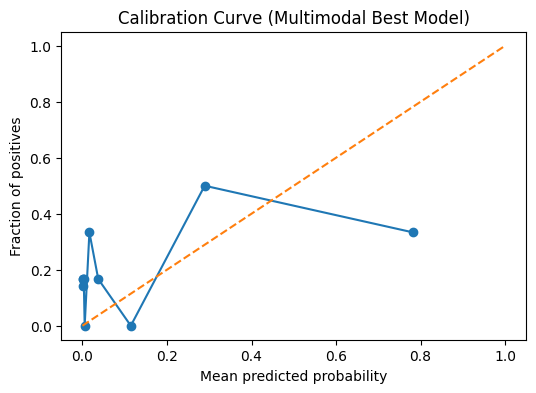

In [30]:
# EARLY-WARNING (LEAD-TIME) + CALIBRATION CHECK
print("="*70)
print("EARLY-WARNING EVALUATION (LEAD-TIME)")
print("="*70)

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Using the final multimodal best model bundle
best_name   = best_name_multimodal
bundle      = results_multimodal[best_name]
best_pipe   = bundle["model"]

X_test      = bundle["X_test"]
y_test      = bundle["y_test"].astype(int)
groups_test = bundle.get("groups_test", None)
weeks_test  = bundle.get("weeks_test", None)

if groups_test is None or weeks_test is None:
    raise ValueError(
        "Missing groups_test / weeks_test in the results bundle. "
        "Re-run the GridSearch section after the updated run_gridsearch() changes."
    )

# Probabilities (if available); otherwise decision function mapped
try:
    if hasattr(best_pipe, "predict_proba"):
        y_proba = best_pipe.predict_proba(X_test)[:, 1]
    else:
        scores  = best_pipe.decision_function(X_test)
        y_proba = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
except Exception:
    # last-resort fallback (prevents crashing)
    y_proba = best_pipe.predict(X_test).astype(float)

# Default threshold
threshold = 0.5
y_pred    = (y_proba >= threshold).astype(int)

# Lead-time evaluation (robust indexing)
# 'week' may be ISO week number (1..52) and can skip values or wrap at year end.
# Creating a per-student sequential index (0,1,2,...) so "previous K observations" is always correct.
df_eval = pd.DataFrame({
    "student_id": groups_test,
    "week":       weeks_test,
    "y_true":     y_test.values,
    "y_proba":    y_proba,
    "y_pred":     y_pred
}).sort_values(["student_id", "week"]).reset_index(drop=True)

# Per-student sequential index of observations (not calendar week)
df_eval["week_idx"] = df_eval.groupby("student_id").cumcount()

# Onset = first observation where y_true becomes 1 after previously 0 (per student)
df_eval["prev"]     = df_eval.groupby("student_id")["y_true"].shift(1).fillna(0).astype(int)
df_eval["is_onset"] = ((df_eval["y_true"] == 1) & (df_eval["prev"] == 0)).astype(int)

K = 3  # look back K previous observations
onset_rows = df_eval[df_eval["is_onset"] == 1].copy()

if len(onset_rows) == 0:
    print("No onset events found in the test split (this can happen with small data).")
else:
    caught = 0
    for _, row in onset_rows.iterrows():
        sid   = row["student_id"]
        t_idx = int(row["week_idx"])

        hist = df_eval[
            (df_eval["student_id"] == sid) &
            (df_eval["week_idx"]   >= t_idx - K) &
            (df_eval["week_idx"]   < t_idx)
        ]

        if (hist["y_pred"] == 1).any():
            caught += 1

    early_detection_rate = caught / len(onset_rows)
    print(f"Onset events in test: {len(onset_rows)}")
    print(f"Caught at least 1 observation early (within last {K} observations): {caught}")
    print(f"Early Detection Rate: {early_detection_rate:.3f}")

# Calibration check
print("\n" + "="*70)
print("CALIBRATION CHECK (PROBABILITIES)")
print("="*70)

try:
    brier = brier_score_loss(y_test, y_proba)
    print(f"Brier score (lower is better): {brier:.4f}")

    frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")

    plt.figure(figsize=(6, 4))
    plt.plot(mean_pred, frac_pos, marker="o")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Calibration Curve (Multimodal Best Model)")
    plt.show()
except Exception as e:
    print("Calibration plot failed:", e)
